# Pipeline Outputs Reference

A complete guide to all files produced by singlify per sample. The pipeline generates
40+ output files covering count matrices, velocity layers, QC metrics, variants, and metadata.

**Sample**: GSM3573650 (human bone marrow)

In [1]:
%matplotlib inline
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120

sample_dir = '/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650'

# List all output files
files = sorted(os.listdir(sample_dir))
print(f"Total output files: {len(files)}")
print(f"\nAll files:")
for f in files:
    size = os.path.getsize(os.path.join(sample_dir, f))
    if size > 1e6:
        print(f"  {f:40s} {size/1e6:.1f} MB")
    else:
        print(f"  {f:40s} {size/1e3:.0f} KB")

Total output files: 41

All files:
  ambient_contamination.tsv                1.9 MB
  ambient_profile.tsv                      18.6 MB
  ambiguous.1pz                            562 KB
  ancestry_call.json                       0 KB
  ase_counts.tsv                           553 KB
  auto_barcodes.tsv                        1.3 MB
  cell_calls.tsv                           3.4 MB
  cell_cycle_scores.tsv                    2.9 MB
  cell_qc_metrics.tsv                      3.1 MB
  donor0.vcf                               48.1 MB
  donor0_coverage.tsv                      31.2 MB
  donor_assignments.tsv                    3.2 MB
  doublet_scores.tsv                       2.6 MB
  exon_counts.1pz                          28.5 MB
  gene_counts.1pz                          24.6 MB
  gene_counts_em.1pz                       1.3 MB
  gene_expression.tsv                      2.0 MB
  intron_counts.1pz                        12.4 MB
  metrics_summary.csv                      0 KB
  mt_heteropl

In [2]:
# Categorize files
categories = {
    'Count Matrices': [f for f in files if f.endswith('.1pz') or f.endswith('.mtx')],
    'QC Metrics': [f for f in files if 'qc' in f or 'metrics' in f or 'doublet' in f or 'ambient' in f],
    'Variant Calling': [f for f in files if 'vcf' in f or 'coverage' in f or 'snp' in f or 'hetero' in f],
    'Cell Annotations': [f for f in files if 'call' in f or 'cycle' in f or 'donor' in f or 'ancestry' in f],
    'Gene Info': [f for f in files if 'feature' in f or 'barcode' in f or 'gene' in f or 'expression' in f],
}

print("Files by Category:")
print("=" * 50)
for cat, cat_files in categories.items():
    total_size = sum(os.path.getsize(os.path.join(sample_dir, f)) for f in cat_files)
    print(f"\n{cat} ({len(cat_files)} files, {total_size/1e6:.1f} MB):")
    for f in sorted(cat_files):
        print(f"  • {f}")

Files by Category:

Count Matrices (13 files, 245.3 MB):
  • ambiguous.1pz
  • exon_counts.1pz
  • gene_counts.1pz
  • gene_counts_em.1pz
  • intron_counts.1pz
  • mt_heteroplasmy.1pz
  • sj_counts.1pz
  • snp_ad.1pz
  • snp_dp.1pz
  • splice_psi.1pz
  • spliced.1pz
  • unspliced.1pz
  • vdj_gene_usage.1pz

QC Metrics (5 files, 26.2 MB):
  • ambient_contamination.tsv
  • ambient_profile.tsv
  • cell_qc_metrics.tsv
  • doublet_scores.tsv
  • metrics_summary.csv

Variant Calling (5 files, 204.8 MB):
  • donor0.vcf
  • donor0_coverage.tsv
  • mt_heteroplasmy.1pz
  • snp_ad.1pz
  • snp_dp.1pz

Cell Annotations (7 files, 88.7 MB):
  • ancestry_call.json
  • cell_calls.tsv
  • cell_cycle_scores.tsv
  • donor0.vcf
  • donor0_coverage.tsv
  • donor_assignments.tsv
  • sex_call.json

Gene Info (5 files, 29.5 MB):
  • auto_barcodes.tsv
  • gene_counts.1pz
  • gene_counts_em.1pz
  • gene_expression.tsv
  • vdj_gene_usage.1pz


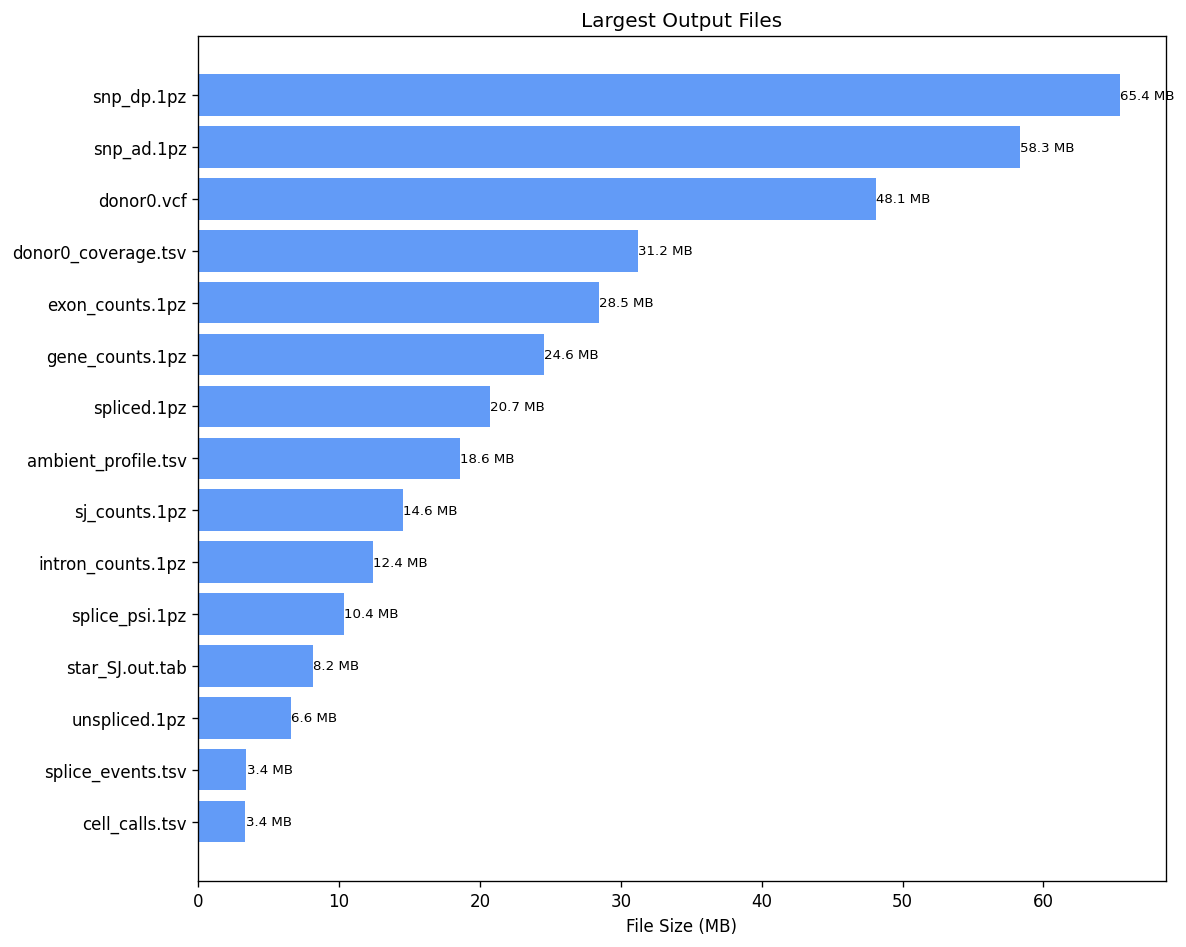


Total output size: 378.8 MB


In [3]:
# File size breakdown
sizes = []
for f in files:
    fp = os.path.join(sample_dir, f)
    sizes.append({'file': f, 'size_mb': os.path.getsize(fp) / 1e6})

size_df = pd.DataFrame(sizes).sort_values('size_mb', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top = size_df.head(15)
ax.barh(range(len(top)), top['size_mb'].values, color='#3b82f6', alpha=0.8)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top['file'].values)
ax.set_xlabel('File Size (MB)')
ax.set_title('Largest Output Files')
ax.invert_yaxis()
for i, v in enumerate(top['size_mb'].values):
    ax.text(v + 0.01, i, f'{v:.1f} MB', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print(f"\nTotal output size: {size_df['size_mb'].sum():.1f} MB")

In [4]:
# Load and preview key files
print("=" * 50)
print("KEY FILE PREVIEWS")
print("=" * 50)

# Metrics summary
print("\n1. metrics_summary.csv:")
# metrics_summary.csv has commas in values, parse manually
metrics_dict = {}
mf = os.path.join(sample_dir, 'metrics_summary.csv')
with open(mf) as fh:
    next(fh)
    for row in fh:
        parts = row.strip().split(',')
        key = parts[0]
        val = ''.join(parts[1:]).strip().rstrip('%')
        try:
            metrics_dict[key] = float(val)
        except ValueError:
            metrics_dict[key] = val
m = pd.DataFrame([metrics_dict])
for col in m.columns:
    print(f"   {col}: {m[col].iloc[0]}")

# Cell QC 
print("\n2. cell_qc_metrics.tsv (first 5 rows):")
qc = pd.read_csv(os.path.join(sample_dir, 'cell_qc_metrics.tsv'), sep='\t', nrows=5)
print(qc.to_string(index=False))

KEY FILE PREVIEWS

1. metrics_summary.csv:
   Estimated Number of Cells: 74236.0
   Mean Reads per Cell: 2319.0
   Median Genes per Cell: 173.0
   Number of Reads: 172182819.0
   Valid Barcodes: 77.8
   Sequencing Saturation: 2.3
   Q30 Bases in Barcode: N/A
   Q30 Bases in RNA Read: N/A
   Q30 Bases in UMI: N/A
   Reads Mapped to Genome: 100.0
   Reads Mapped Confidently to Transcriptome: 61.4
   Reads Mapped Confidently to Intronic Regions: 7.8
   Fraction Reads in Cells: 43.2
   Total Genes Detected: 26850.0
   Median UMI Counts per Cell: 228.0

2. cell_qc_metrics.tsv (first 5 rows):
         barcode  total_umis  total_genes  mt_pct  ribo_pct  intronic_pct
GGATGTTTCCGCGCAA       63704         8615    2.05     35.12         11.99
CACATAGAGCAGATCG       49130         7709    2.35     43.25         12.93
CCACCTAAGCCAGGAT       46024         7801    1.81     38.87         16.63
AACACGTGTCCAGTTA       45081         8075    4.11     29.38         17.14
ACAGCCGGTAATTGGA       44259        

In [5]:
# Loading guide
import singlet

print("=" * 50)
print("LOADING GUIDE")
print("=" * 50)

print("""
# Load everything as AnnData (recommended):
adata = singlet.load_dir('/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650')

# Load individual matrices:
gene_mat = singlet.read_1pz('/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650/gene_counts.1pz')
exon_mat = singlet.read_1pz('/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650/exon_counts.1pz')
intron_mat = singlet.read_1pz('/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650/intron_counts.1pz')

# Load QC annotations separately:
doublets = pd.read_csv('/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650/doublet_scores.tsv', sep='\t')
cell_cycle = pd.read_csv('/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650/cell_cycle_scores.tsv', sep='\t')
ambient = pd.read_csv('/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650/ambient_contamination.tsv', sep='\t')
""")


LOADING GUIDE

# Load everything as AnnData (recommended):
adata = singlet.load_dir('/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650')

# Load individual matrices:
gene_mat = singlet.read_1pz('/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650/gene_counts.1pz')
exon_mat = singlet.read_1pz('/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650/exon_counts.1pz')
intron_mat = singlet.read_1pz('/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650/intron_counts.1pz')

# Load QC annotations separately:
doublets = pd.read_csv('/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650/doublet_scores.tsv', sep='	')
cell_cycle = pd.read_csv('/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650/cell_cycle_scores.tsv', sep='	')
ambient = pd.read_csv('/mnt/projects/debruinz_project/sin

## Summary

singlify produces a comprehensive output directory per sample:

| Category | Files | Description |
|----------|-------|-------------|
| **Count Matrices** | gene_counts.1pz, exon_counts.1pz, intron_counts.1pz | Sparse matrices in .1pz format |
| **QC Metrics** | cell_qc_metrics.tsv, doublet_scores.tsv, ambient_contamination.tsv | Per-cell quality annotations |
| **Variants** | donor0.vcf, mt_heteroplasmy.1pz, donor0_coverage.tsv | SNP genotypes + MT variants |
| **Annotations** | cell_calls.tsv, cell_cycle_scores.tsv, ancestry_call.json | Cell-level annotations |
| **Summary** | metrics_summary.csv | Sample-level metrics |

Use `singlet.load_dir()` to load all of these into a single AnnData object.